In [1]:
import os, sys
import numpy as np
import pandas as pd
import scanpy as sc

In [2]:
import torch
import PINN
from PINN import reader, models, pl, tl

import matplotlib.pyplot as plt

In [3]:
from TorchDiffEqPack import odesolve
from torchdiffeq import odeint

In [4]:
os.chdir("../../")

In [5]:
# CHANG THIS !!!!!
ckpt_path = "logs/TwoTimpepoint_u_dt_n7/lightning_logs/version_3/checkpoints/epoch=59-total_loss=0.00000645.ckpt"

In [6]:
adata = sc.read_h5ad(f"data/tom_pos.h5ad")

In [7]:
import matplotlib.pyplot as plt

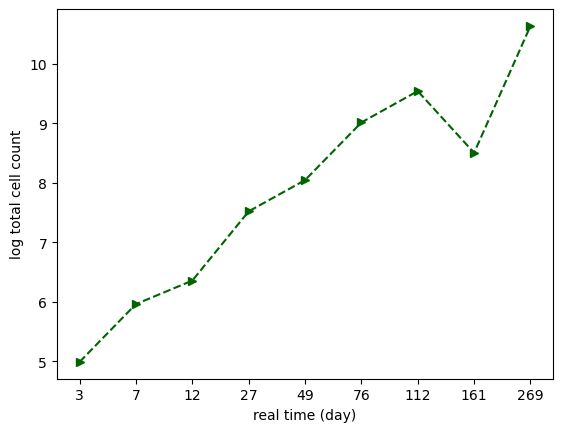

In [22]:
old_pop = [147. , 388.64570792, 576.69290022, 1846.6599877 , 3123.27770491, 8233.9326366 , 13949.54802458, 4941.85061577, 41722.98597037]


plt.plot(np.log(old_pop), '--', marker='>', color='darkgreen')
# plt.plot(np.log(adata.uns['pop']['mean']), marker='o')


plt.ylabel("log total cell count")
plt.xlabel("real time (day)")
plt.xticks(range(9), adata.uns['pop']['t']);

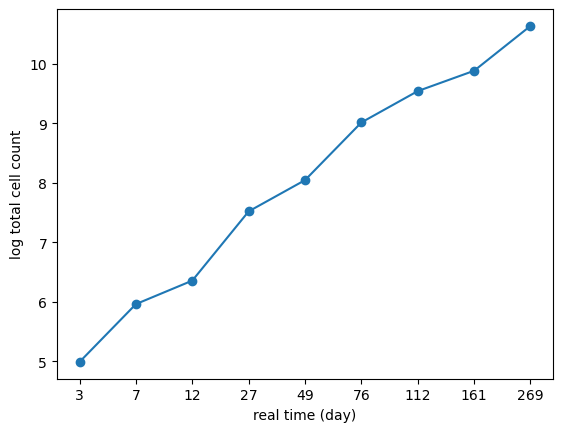

In [13]:
plt.plot(np.log(adata.uns['pop']['mean']), marker='o')
plt.ylabel("log total cell count")
plt.xlabel("real time (day)")
plt.xticks(range(9), adata.uns['pop']['t']);

In [23]:
adata.uns['pop']['mean']

array([  147.        ,   388.64570792,   576.69290022,  1846.6599877 ,
        3123.27770491,  8233.9326366 , 13949.54802458, 19636.45034395,
       41722.98597037])

In [37]:
d8_pop = np.exp(y_pred[7])

In [39]:
adata.uns['original_pop'] = adata.uns['pop'].copy()

In [40]:
popD = adata.uns['original_pop'].copy()

In [55]:
N7 = popD['mean'][6]
N9 = popD['mean'][8]
a = np.log(N9/N7) / (269-112)
N8 = N7*np.exp(a*(161-112))

In [63]:
popD['mean'][7] = N8

In [64]:
adata.uns['pop'] = popD

In [67]:
adata.write_h5ad("data/tom_pos.h5ad")

# load data

In [6]:
# MODEL CLASS and define model
mlp_model = models.u_dt.load_from_checkpoint(ckpt_path)
device = mlp_model.device

In [7]:
adata = sc.read_h5ad(f"data/tom_pos.h5ad")
timepoints = adata.uns['pop']['t']

cellstate_key = "DM_scaled"

n_timepoint = 7
n_dimension =10

# the DS
DS_t7 = reader.TwoTimpepoint_AnnDS(AnnData=adata, n_timepoint=n_timepoint,  
                            n_dimension = n_dimension,
                              cellstate_key=cellstate_key,  #'DM_EigenVector'
                              log_transform=False,
                              norm_time=False,
                              batchsize = 300
                              )

In [8]:
t7_ad = DS_t7.adata.copy()

u_b = DS_t7.u_b.cpu().numpy().reshape(n_timepoint, -1)

cellstate = torch.from_numpy(DS_t7.cellstate).float().requires_grad_()

In [9]:
t_list = timepoints / 15
t_list

array([ 0.2       ,  0.46666667,  0.8       ,  1.8       ,  3.26666667,
        5.06666667,  7.46666667, 10.73333333, 17.93333333])

In [10]:
from tqdm.auto import tqdm

In [13]:
u_t_ls = []
chunk_size= 200
t_list = timepoints / 15

for i in tqdm(range(0, len(cellstate), chunk_size)):

    s0 = cellstate[i:i+chunk_size].to(device)
    tompos_u0 = torch.from_numpy(u_b[0, i:i+chunk_size]).float().to(device).requires_grad_()
    init_condition = (tompos_u0, s0)

    u_t, s_t = odeint(
                    mlp_model.ode_func,
                    init_condition,
                    torch.tensor(t_list).type(torch.float32).to(device),
                    atol=1e-5,
                    rtol=1e-5,
                    method='midpoint',
                    options = {'step_size': 0.1}
                )

    torch.cuda.empty_cache()

    u_t_ls.append(u_t.detach().cpu().numpy())
    del u_t, s_t
    torch.cuda.empty_cache()

  0%|          | 0/130 [00:00<?, ?it/s]

In [ ]:
]

In [14]:
u_int = np.concatenate(u_t_ls, axis=1)

In [15]:
u_b.shape, u_int.shape

((7, 25948), (9, 25948))

prediction of shape (7, 25948)
prediction of shape (7, 25948)


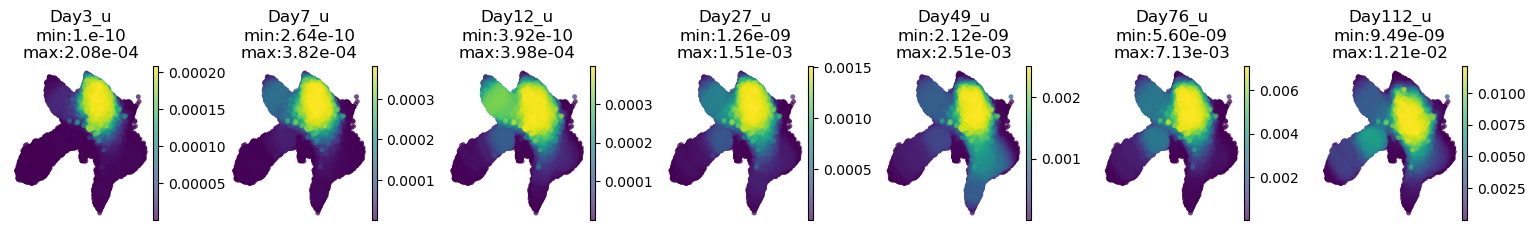

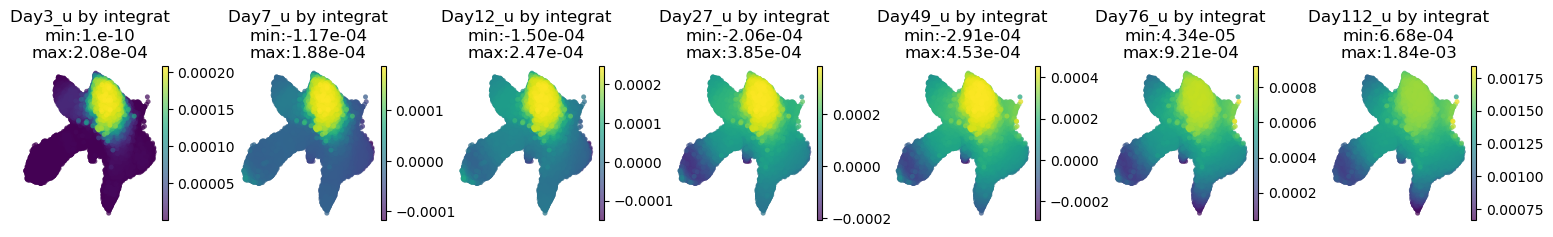

In [16]:
PINN.pl.params_in_umap(t7_ad, u_b, param='u', cell_of_t=False);
PINN.pl.params_in_umap(t7_ad, u_int[:-2], param='u by integrat', cell_of_t=False);

prediction of shape (9, 25948)


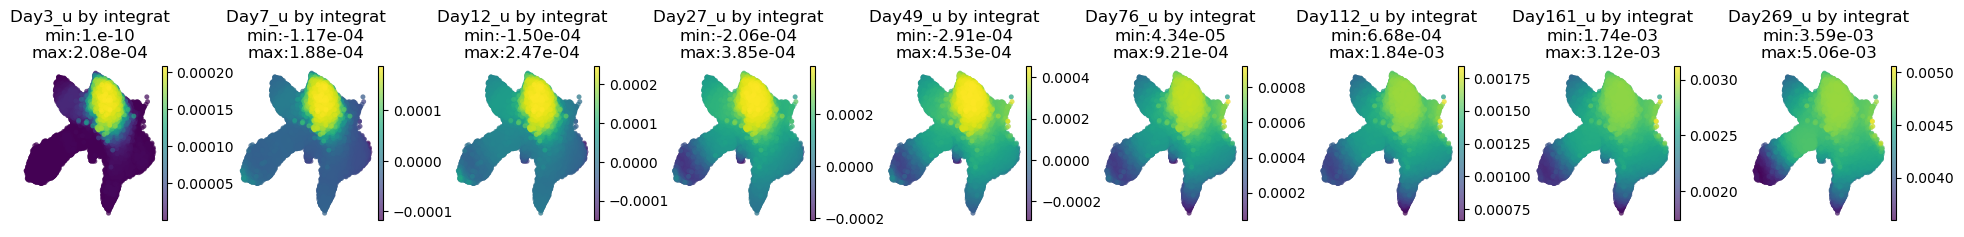

In [17]:
PINN.pl.params_in_umap(t7_ad, u_int,  timepoints=timepoints, param='u by integrat', cell_of_t=False);

# testing

In [14]:
np.log(1e-10)

-23.025850929940457

In [15]:
np.sqrt((np.log(1e-10) - np.log(1e-30))**2)

46.05170185988091

In [17]:
np.sqrt((np.log(1e-4) - np.log(1e-2))**2)

4.605170185988091

In [24]:
weight = []
u_tests = []
u_test  = 1e-2
for i in range(10):
    u_test  = u_test/10
    u_tests.append(u_test)
    weight.append(20 + np.log(u_test))

In [ ]:
u_0

In [ ]:
weight = [20+torch.log(u) for u in ]

In [22]:
weight

[13.092244721017863,
 10.789659628023818,
 8.487074535029771,
 6.184489442035726,
 3.8819043490416796,
 1.5793192560476363,
 -0.7232658369464104,
 -3.0258509299404572,
 -5.328436022934504,
 -7.631021115928547]

In [30]:
i = 0
chunk_size=300
u0 = torch.from_numpy(u_b[0, i:i+chunk_size]).float()

In [31]:
i = 800
chunk_size=300
u_target = torch.from_numpy(u_b[0, i:i+chunk_size]).float()

In [50]:
u0 = torch.clamp(u0, min=1e-9)
u_target = torch.clamp(u_target, min=1e-9)

weight = (23+torch.log(u0))**2
weight /= weight.sum()


In [61]:
if torch.all(u0 >0):
    print('yes')

yes


In [54]:
u0[weight.argmax().item()]

tensor(0.0002)

In [55]:
u0[weight.argmin().item()]

tensor(1.0000e-09)

In [36]:
loss_fn = torch.nn.MSELoss()

In [57]:
def weighted_mse_loss(input, target, weight):
    return weight * (input - target) ** 2

In [58]:
weighted_mse_loss(torch.log(u_target), torch.log(u0), weight)

tensor([2.4503e-02, 7.2046e-01, 5.5542e-01, 6.9420e-01, 7.2464e-03, 6.7292e-02,
        1.0512e-01, 1.2267e-01, 9.1225e-02, 2.3603e-02, 3.7834e-03, 3.6323e-02,
        1.1618e-04, 7.0801e-03, 6.1853e-03, 3.0625e-02, 1.1948e-03, 7.1930e-02,
        1.0389e-03, 1.1842e-02, 2.3639e-04, 6.4845e-01, 3.0813e-02, 3.0822e-02,
        4.8045e-02, 2.8844e-02, 1.3855e-01, 2.3666e-02, 8.2994e-06, 2.3975e-03,
        5.1570e-04, 2.2046e-02, 3.4873e-02, 1.9191e-03, 6.4932e-01, 7.5306e-01,
        2.1106e-05, 8.8259e-03, 5.6110e-04, 6.7914e-04, 5.3859e-02, 1.9214e-02,
        7.1420e-03, 5.6406e-03, 2.0607e-04, 6.4183e-03, 5.6956e-03, 6.6531e-03,
        8.2507e-04, 1.4758e-02, 5.2611e-04, 1.2348e-02, 5.8394e-03, 1.6586e-02,
        2.8258e-02, 3.7068e-02, 8.2985e-04, 3.5293e-03, 6.4250e-02, 6.8824e-02,
        6.8776e-01, 2.8815e-01, 1.2559e-02, 1.1934e-02, 3.6608e-01, 1.3423e-02,
        9.5582e-02, 1.4554e-02, 6.8880e-01, 7.4537e-01, 2.4687e-01, 1.7401e-02,
        1.5746e-03, 1.9422e-04, 5.6180e-

In [35]:
weight

tensor([ 8.5334, 11.3180, 11.2135, 11.1972, 10.9017, 10.9379, 10.7942, 11.0286,
        11.1412, 10.5909, 11.3495,  6.5721, 11.0241, 10.0916,  6.8033,  8.3291,
        10.6932, 10.8734, 10.9853, 11.3567, 11.4828, 10.9782,  8.2647, 11.4092,
         6.8121,  8.7822, 11.4128,  3.8431,  9.8740, 10.5194, 11.3052, 11.4706,
        10.1667,  9.7914, 10.9825, 11.4636, 10.9414,  8.5482, 10.4994, 10.9021,
        10.5292, 10.7720, 10.9330,  9.7611, 11.2244, 10.2011,  9.1210, 11.0891,
        10.9147, 10.6227, 11.0676, -0.7233, 10.3076, 11.0989,  8.9436,  4.4947,
        11.3401, -0.7233, 10.7801, 10.8902, 11.1670,  8.6422, 11.1649, -0.7233,
        10.9042,  9.5534,  8.6832,  8.9189, 11.1719, 11.4297,  8.2486, 11.2495,
        10.8034, 11.3682, 11.3088, 11.3974,  9.3495,  8.5908,  8.3198, 11.0341,
        11.4360, -0.7233, 10.4202, 10.9420, 11.1277, 10.8201, 11.3605, 11.2054,
        11.1916, 11.1926, 11.2644, 11.3097, 11.3165, 11.0711,  7.7060, 10.6659,
         9.1447, 11.2573,  6.5172, 10.94